<a href="https://colab.research.google.com/github/Angietzan/Telecom_X_2_LATAM/blob/main/Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [291]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [292]:
import pandas as pd
datos = pd.read_csv('/content/telecomx1.csv')
datos

,Unnamed: 0,customerID,Churn,indice,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0,0002-ORFBO,No,0,Female,False,True,True,9,True,...,True,True,True,True,True,One year,True,Mailed check,65.60,593.3
1,1,0003-MKNFE,No,1,Male,False,True,True,9,True,...,True,True,True,True,True,Month-to-month,True,Mailed check,59.90,542.4
2,2,0004-TLHLJ,Yes,2,Male,False,True,True,4,True,...,True,True,True,True,True,Month-to-month,True,Electronic check,73.90,280.85
3,3,0011-IGKFF,Yes,3,Male,True,True,True,13,True,...,True,True,True,True,True,Month-to-month,True,Electronic check,98.00,1237.85
4,4,0013-EXCHZ,Yes,4,Female,True,True,True,3,True,...,True,True,True,True,True,Month-to-month,True,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,7038,9987-LUTYD,No,7262,Female,False,True,True,13,True,...,True,True,True,True,True,One year,True,Mailed check,55.15,742.9
7039,7039,9992-RRAMN,Yes,7263,Male,False,True,True,22,True,...,True,True,True,True,True,Month-to-month,True,Electronic check,85.10,1873.7
7040,7040,9992-UJOEL,No,7264,Male,False,True,True,2,True,...,True,True,True,True,True,Month-to-month,True,Mailed check,50.30,92.75
7041,7041,9993-LHIEB,No,7265,Male,False,True,True,67,True,...,True,True,True,True,True,Two year,True,Mailed check,67.85,4627.65


In [293]:
datos = datos.drop(columns='customerID')
datos = datos.drop(columns='indice')
datos = datos.drop(columns='Charges.Monthly')
datos.columns

Index(['Unnamed: 0', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Total'],
      dtype='object')

In [294]:
datos

,Unnamed: 0,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Total
0,0,No,Female,False,True,True,9,True,True,DSL,True,True,True,True,True,True,One year,True,Mailed check,593.3
1,1,No,Male,False,True,True,9,True,True,DSL,True,True,True,True,True,True,Month-to-month,True,Mailed check,542.4
2,2,Yes,Male,False,True,True,4,True,True,Fiber optic,True,True,True,True,True,True,Month-to-month,True,Electronic check,280.85
3,3,Yes,Male,True,True,True,13,True,True,Fiber optic,True,True,True,True,True,True,Month-to-month,True,Electronic check,1237.85
4,4,Yes,Female,True,True,True,3,True,True,Fiber optic,True,True,True,True,True,True,Month-to-month,True,Mailed check,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,7038,No,Female,False,True,True,13,True,True,DSL,True,True,True,True,True,True,One year,True,Mailed check,742.9
7039,7039,Yes,Male,False,True,True,22,True,True,Fiber optic,True,True,True,True,True,True,Month-to-month,True,Electronic check,1873.7
7040,7040,No,Male,False,True,True,2,True,True,DSL,True,True,True,True,True,True,Month-to-month,True,Mailed check,92.75
7041,7041,No,Male,False,True,True,67,True,True,DSL,True,True,True,True,True,True,Two year,True,Mailed check,4627.65


In [295]:
datos['Churn'] = datos['Churn'].replace({'Yes': 1, 'No': 0})
datos['gender'] = datos['gender'].replace({'Female': 1, 'Male': 0})
datos['Partner'] = datos['Partner'].replace({True: 1, False: 0})
datos['Dependents'] = datos['Dependents'].replace({True: 1, False: 0})
datos['PhoneService'] = datos['PhoneService'].replace({True: 1, False: 0})
datos['PaperlessBilling'] = datos['PaperlessBilling'].replace({True: 1, False: 0})
datos['SeniorCitizen'] = datos['SeniorCitizen'].replace({True: 1, False: 0})
datos['MultipleLines'] = datos['MultipleLines'].replace({True: 1, False: 0})
datos['OnlineSecurity'] = datos['OnlineSecurity'].replace({True: 1, False: 0})
datos['OnlineBackup'] = datos['OnlineBackup'].replace({True: 1, False: 0})
datos['DeviceProtection'] = datos['DeviceProtection'].replace({True: 1, False: 0})
datos['TechSupport'] = datos['TechSupport'].replace({True: 1, False: 0})
datos['StreamingTV'] = datos['StreamingTV'].replace({True: 1, False: 0})
datos['StreamingMovies'] = datos['StreamingMovies'].replace({True: 1, False: 0})


/tmp/ipykernel_779/1067445851.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos['Churn'] = datos['Churn'].replace({'Yes': 1, 'No': 0})
/tmp/ipykernel_779/1067445851.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos['gender'] = datos['gender'].replace({'Female': 1, 'Male': 0})
/tmp/ipykernel_779/1067445851.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future

In [296]:
columnas = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection','TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract','PaymentMethod']


In [297]:
datos_encode = pd.get_dummies(data=datos, columns=columnas, dtype=int)
datos_encode.sample(5)

,Unnamed: 0,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Total,...,TechSupport_1,StreamingTV_1,StreamingMovies_1,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6258,6258,0,0,0,1,1,63,1,1,1237.65,...,1,1,1,0,0,1,0,0,0,1
5760,5760,0,1,0,1,1,43,1,1,2737.05,...,1,1,1,1,0,0,0,0,1,0
4801,4801,0,0,0,1,1,19,1,1,386.5,...,1,1,1,0,1,0,0,1,0,0
2214,2214,0,1,0,1,1,60,1,1,6236.75,...,1,1,1,1,0,0,1,0,0,0
4229,4229,0,0,0,1,1,47,1,1,1160.45,...,1,1,1,0,0,1,0,0,0,1


In [298]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        7043 non-null   int64 
 1   Churn             7043 non-null   int64 
 2   gender            7043 non-null   int64 
 3   SeniorCitizen     7043 non-null   int64 
 4   Partner           7043 non-null   int64 
 5   Dependents        7043 non-null   int64 
 6   tenure            7043 non-null   int64 
 7   PhoneService      7043 non-null   int64 
 8   MultipleLines     7043 non-null   int64 
 9   InternetService   7043 non-null   object
 10  OnlineSecurity    7043 non-null   int64 
 11  OnlineBackup      7043 non-null   int64 
 12  DeviceProtection  7043 non-null   int64 
 13  TechSupport       7043 non-null   int64 
 14  StreamingTV       7043 non-null   int64 
 15  StreamingMovies   7043 non-null   int64 
 16  Contract          7043 non-null   object
 17  PaperlessBilli

In [299]:
datos_churn = datos['Churn'].value_counts()

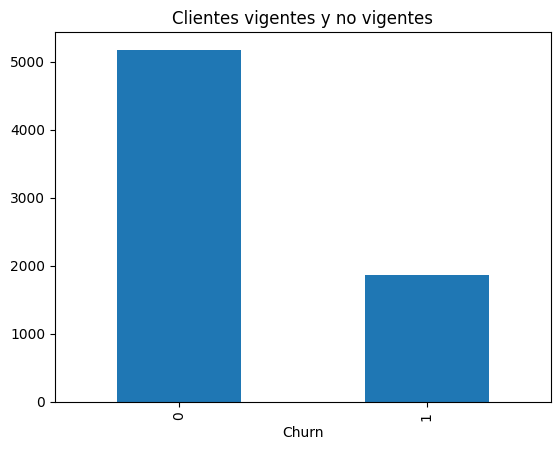

In [300]:
datos_churn.plot(kind='bar')
plt.title('Clientes vigentes y no vigentes')
plt.show()

In [301]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler, SMOTE

In [ ]:
X = datos.drop('Churn', axis=1)
y = datos['Churn']


ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X, y)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)


In [303]:
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.3, random_state=42, stratify=y_smote
)


mdt = DecisionTreeClassifier(random_state=42, max_depth=8)
mdt.fit(X_train, y_train)


y_pred = mdt.predict(X_test)

print("matriz de confusion:\n\n", confusion_matrix(y_test, y_pred))
print("reporte de clasificion:\n", classification_report(y_test, y_pred))

matriz de confusion:

 [[1080  473]
 [ 490 1062]]
reporte de clasificion:
               precision    recall  f1-score   support

          No       0.69      0.70      0.69      1553
         Yes       0.69      0.68      0.69      1552

    accuracy                           0.69      3105
   macro avg       0.69      0.69      0.69      3105
weighted avg       0.69      0.69      0.69      3105



In [ ]:
corr = datos.corr()


plt.figure(figsize=(10,5))
sns.heatmap(corr, cmap="rocket_r", center=0, annot=False)
plt.title("matriz de correlacion")
plt.show()

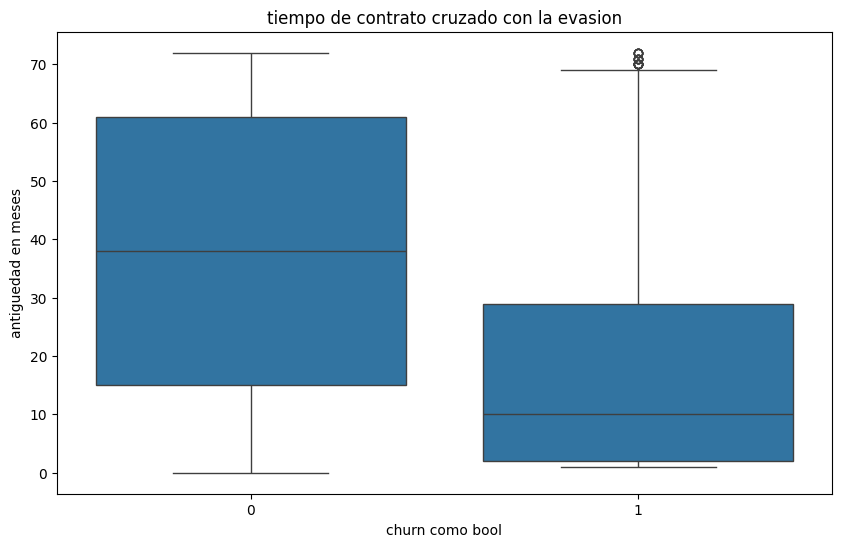

In [305]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Churn", y="tenure", data=datos)
plt.title("tiempo de contrato cruzado con la evasion")
plt.xlabel("churn como bool")
plt.ylabel("antiguedad en meses")
plt.show()

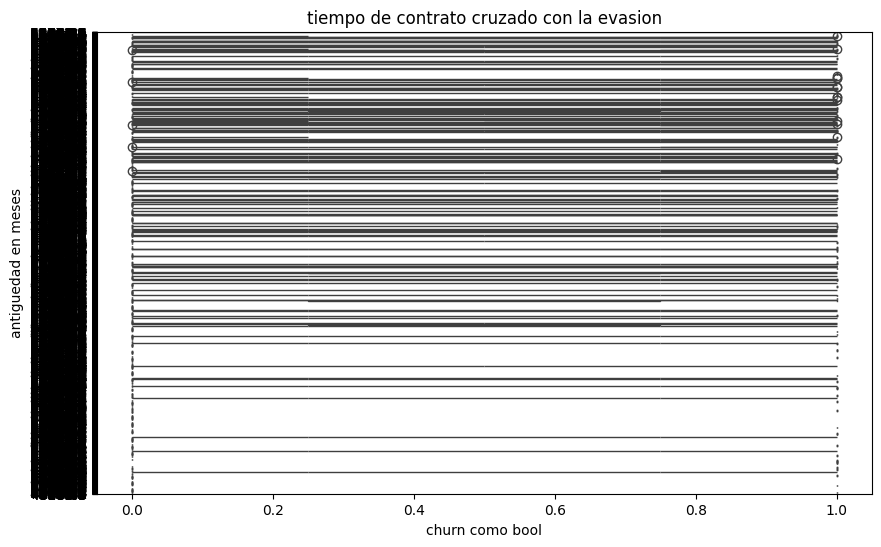

In [308]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Churn", y="Charges.Total", data=datos)
plt.title("tiempo de contrato cruzado con la evasion")
plt.xlabel("churn como bool")
plt.ylabel("antiguedad en meses")
plt.show()

In [309]:
from sklearn.model_selection import train_test_split

X = X_smote
y = y_smote

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

X_train.shape
X_test.shape

(3105, 15)

In [310]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe_log = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
                    ])

pipe_log.fit(X_train, y_train)
y_pred_log = pipe_log.predict(X_test)

In [311]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def modelo(nome, y_true, y_pred):
    print(f" {nome} ")
    print("exactitud:", accuracy_score(y_true, y_pred))
    print("precision:", precision_score(y_true, y_pred))
    print("recall:", recall_score(y_true, y_pred))
    print("f1:", f1_score(y_true, y_pred))
    print("\nmatriz de confusion:\n", confusion_matrix(y_true, y_pred))
    print("\informe de classificacion:\n\n", classification_report(y_true, y_pred))


modelo("regresion logística", y_test, y_pred_log)
modelo("random forest", y_test, y_pred_rf)


**INFORME FINAL**

Conforme la informacion que se pudo recabar, se llega a la conclusion de que las personas abandonan el servicio en el periodo comprendido entre el primer y el segundo mes, que es donde se registro el abandono mas alto.

y aquellos clientes que pagan la suscripcion por 1 o 2 años es quienes menos tasa de abandono presentan, asi tambien se menciona que el metodo de pago mas usado tanto por hombres como por mujeres es el cheque electronico. mientras que el pago con efectivo es el que menos se ve usado.

Por ello se concluye que aquellos clientes que desarrollan permanencia es por contratos largos, que utilizan un metodo de pago de cheque electronico.


**RECOMENDACIONES**

Se recomienda incentivar aquellos parametros que aseguran la permanencia de los clientes, tales como los contratos a largo plazo, fomentar los paquetes de servicios en combo para afianzar nuevos clientes y que estos generaren antiguedad.